In [ ]:
!nvidia-smi

Fri Jun 19 17:07:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/traffic_project"

folders = [
    "datasets",
    "models",
    "outputs",
    "notebooks"
]

for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [ ]:
!pip install ultralytics
!pip install easyocr
!pip install supervision
!pip install opencv-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 66.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 32.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.6/273.6 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.7/102.7 kB 13.5 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

print("YOLOv8 installed successfully!")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLOv8 installed successfully!


In [ ]:
model = YOLO('yolov8n.pt')

In [ ]:
import os

dataset_path = "/content/drive/MyDrive/traffic_project/datasets"

print(os.listdir(dataset_path))

['triple_dataset.zip', 'triple_dataset']


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving triple_dataset.zip to triple_dataset.zip


In [ ]:
!ls /content

drive  sample_data  yolov8n.pt


In [ ]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/traffic_project/datasets/triple_dataset.zip"
extract_path = "/content/drive/MyDrive/traffic_project/datasets/triple_dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive/traffic_project/datasets/triple_dataset"))

['test', 'train', 'valid', 'data.yaml', 'README.roboflow.txt', 'README.dataset.txt']


In [ ]:
!pip install pandas matplotlib seaborn tqdm

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm import tqdm

In [ ]:
dataset_path = "/content/drive/MyDrive/traffic_project/datasets/triple_dataset"

In [ ]:
train_images = len(os.listdir(dataset_path+"/train/images"))
valid_images = len(os.listdir(dataset_path+"/valid/images"))
test_images = len(os.listdir(dataset_path+"/test/images"))

print("Train Images :", train_images)
print("Validation Images :", valid_images)
print("Test Images :", test_images)

Train Images : 2053
Validation Images : 586
Test Images : 291


In [ ]:
class_counter = Counter()

splits = ["train", "valid", "test"]

for split in splits:

    label_dir = os.path.join(dataset_path, split, "labels")

    for file in tqdm(os.listdir(label_dir)):

        with open(os.path.join(label_dir,file),"r") as f:

            lines = f.readlines()

            for line in lines:

                cls = int(line.split()[0])

                class_counter[cls]+=1

print(class_counter)

100%|██████████| 291/291 [00:01<00:00, 267.92it/s]

Counter({1: 1158, 0: 411, 2: 380})


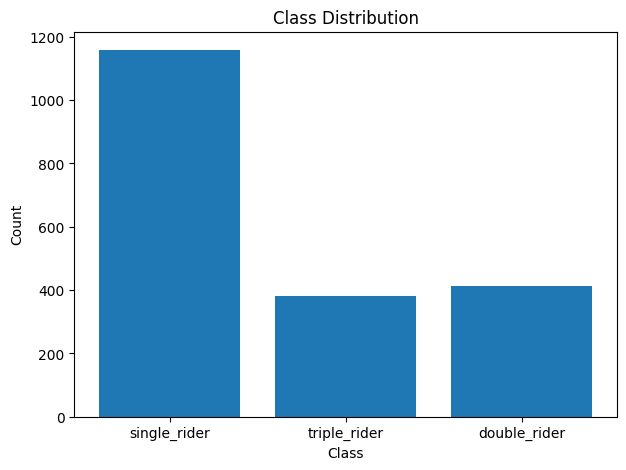

In [ ]:
classes = {
0:"double_rider",
1:"single_rider",
2:"triple_rider"
}

x = [classes[i] for i in class_counter.keys()]
y = list(class_counter.values())

plt.figure(figsize=(7,5))

plt.bar(x,y)

plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")

plt.show()

In [ ]:
empty_labels = 0

for split in splits:

    label_dir = os.path.join(dataset_path, split, "labels")

    for file in os.listdir(label_dir):

        path = os.path.join(label_dir, file)

        if os.path.getsize(path) == 0:

            empty_labels += 1

print("Empty Label Files =", empty_labels)

Empty Label Files = 1364


In [ ]:
bad_boxes=[]

for split in splits:

    label_dir=os.path.join(dataset_path,split,"labels")

    for file in os.listdir(label_dir):

        with open(os.path.join(label_dir,file),"r") as f:

            lines=f.readlines()

            for line in lines:

                cls,xc,yc,w,h=map(float,line.split())

                if not(
                    0<=xc<=1 and
                    0<=yc<=1 and
                    0<w<=1 and
                    0<h<=1
                ):

                    bad_boxes.append(file)

print("Invalid Boxes =",len(bad_boxes))

Invalid Boxes = 0


In [ ]:
objects_per_image=[]

for split in splits:

    label_dir=os.path.join(dataset_path,split,"labels")

    for file in os.listdir(label_dir):

        with open(os.path.join(label_dir,file),"r") as f:

            objects_per_image.append(len(f.readlines()))

print("Average Objects/Image =",np.mean(objects_per_image))
print("Maximum Objects/Image =",max(objects_per_image))

Average Objects/Image = 0.6651877133105802
Maximum Objects/Image = 4


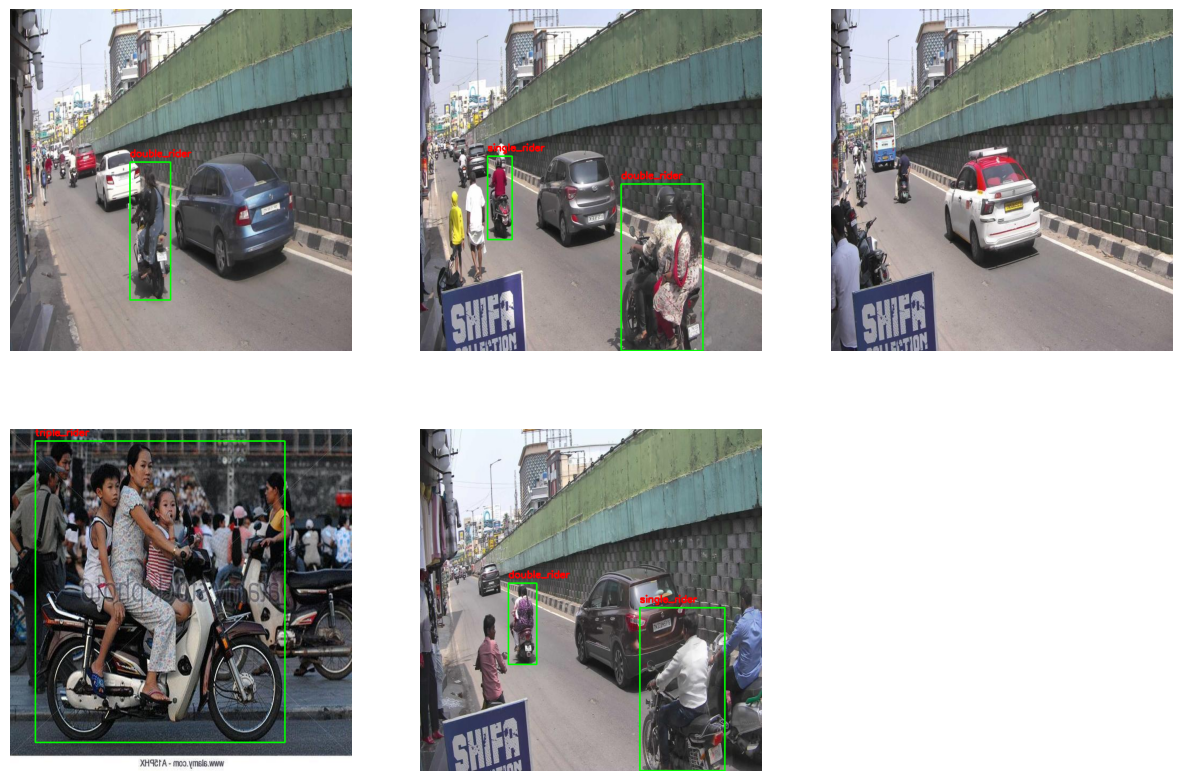

In [ ]:
import random
import cv2

split = "train"

image_dir = os.path.join(dataset_path, split, "images")
label_dir = os.path.join(dataset_path, split, "labels")

classes = {
    0:"double_rider",
    1:"single_rider",
    2:"triple_rider"
}

image_files = os.listdir(image_dir)

sample_images = random.sample(image_files,5)

plt.figure(figsize=(15,10))

for idx,image_file in enumerate(sample_images):

    image_path = os.path.join(image_dir,image_file)

    image = cv2.imread(image_path)
    image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

    h,w,_ = image.shape

    label_path = os.path.join(label_dir,image_file.replace(".jpg",".txt"))

    if os.path.exists(label_path):

        with open(label_path) as f:

            lines=f.readlines()

            for line in lines:

                cls,xc,yc,bw,bh = map(float,line.split())

                x1=int((xc-bw/2)*w)
                y1=int((yc-bh/2)*h)

                x2=int((xc+bw/2)*w)
                y2=int((yc+bh/2)*h)

                cv2.rectangle(image,(x1,y1),(x2,y2),(0,255,0),2)

                cv2.putText(image,
                            classes[int(cls)],
                            (x1,y1-10),
                            cv2.FONT_HERSHEY_SIMPLEX,
                            0.6,
                            (255,0,0),
                            2)

    plt.subplot(2,3,idx+1)
    plt.imshow(image)
    plt.axis("off")

plt.show()

In [ ]:
data_yaml = """
path: /content/drive/MyDrive/traffic_project/datasets/triple_dataset

train: train/images
val: valid/images
test: test/images

names:
  0: double_rider
  1: single_rider
  2: triple_rider
"""

with open("data.yaml","w") as f:
    f.write(data_yaml)

print("data.yaml created")

data.yaml created


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

In [ ]:
results = model.train(

    data="data.yaml",

    epochs=100,

    imgsz=512,

    batch=8,

    optimizer="AdamW",

    lr0=0.001,

    patience=20,

    workers=2,

    cache=False,

    device=0,

    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,

    translate=0.1,
    scale=0.5,

    fliplr=0.5,

    mosaic=1.0,

    mixup=0.1,

    project="/content/drive/MyDrive/traffic_project/models",

    name="triple_rider_yolov8n"

)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=triple_rider_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=20, perspe

In [ ]:
from ultralytics import YOLO

best_model = YOLO(
"/content/drive/MyDrive/traffic_project/models/triple_rider_yolov8n/weights/best.pt"
)

In [ ]:
metrics = best_model.val()

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.7±0.3 ms, read: 30.1±9.6 MB/s, size: 63.3 KB)
val: Scanning /content/drive/MyDrive/traffic_project/datasets/triple_dataset/valid/labels.cache... 586 images, 278 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 586/586 144.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 37/37 4.0it/s 9.3s
                   all        586        378      0.913      0.882      0.951      0.874
          double_rider         78         83      0.894      0.812      0.916      0.847
          single_rider        175        217      0.896      0.911      0.967      0.878
          triple_rider         78         78      0.951      0.923      0.969      0.895
Speed: 1.8ms preprocess, 2.9ms inference, 0.0ms loss, 1.7ms postprocess per image
Results sav

In [ ]:
import os
import random

image_dir = "/content/drive/MyDrive/traffic_project/datasets/triple_dataset/test/images"

img = random.choice(os.listdir(image_dir))

print(img)

2643_TN30BQ1107_1775479388000_2026-04-06-12-43-08_background_jpg.rf.6d6704ad15522235a91a0863979b910b.jpg


In [ ]:
image_path = os.path.join(image_dir, img)

results = best_model.predict(
    source=image_path,
    conf=0.5,
    save=True
)


image 1/1 /content/drive/MyDrive/traffic_project/datasets/triple_dataset/test/images/2643_TN30BQ1107_1775479388000_2026-04-06-12-43-08_background_jpg.rf.6d6704ad15522235a91a0863979b910b.jpg: 512x512 (no detections), 9.0ms
Speed: 3.3ms preprocess, 9.0ms inference, 0.9ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/runs/detect/predict


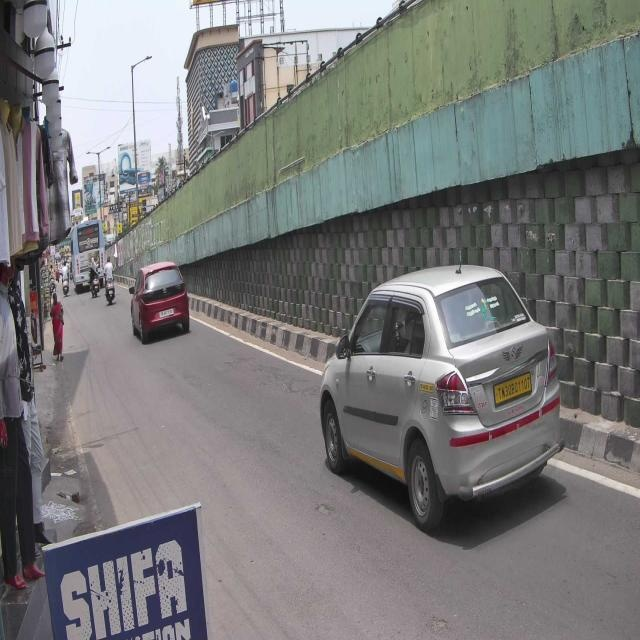

In [ ]:
from IPython.display import Image

Image("/content/runs/detect/predict/" + img)

Results saved to /content/runs/detect/predict

 4977_TN90J3861_1775841598000_2026-04-10-17-19-58_background_jpg.rf.647a7b31cc848435cbcb03546925a3d0.jpg


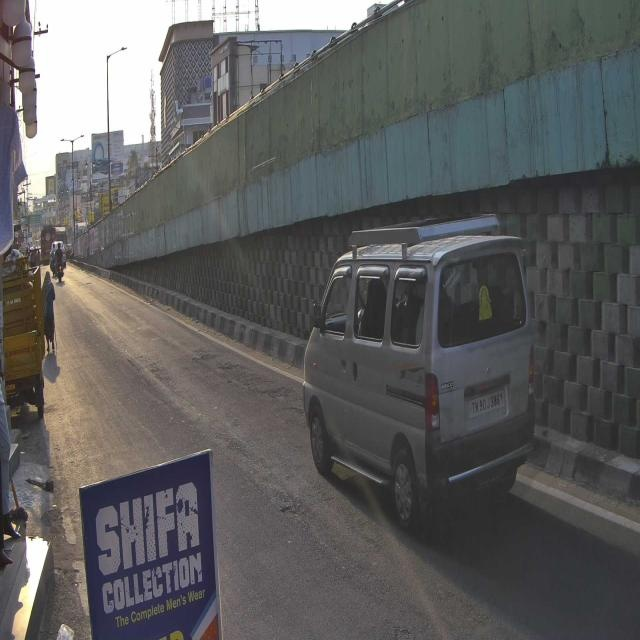

Results saved to /content/runs/detect/predict

 1330_KA01MY3430_1775473871000_2026-04-06-11-11-11_background_jpg.rf.fabd0885cef9bc4a7450ee242da1a35e.jpg


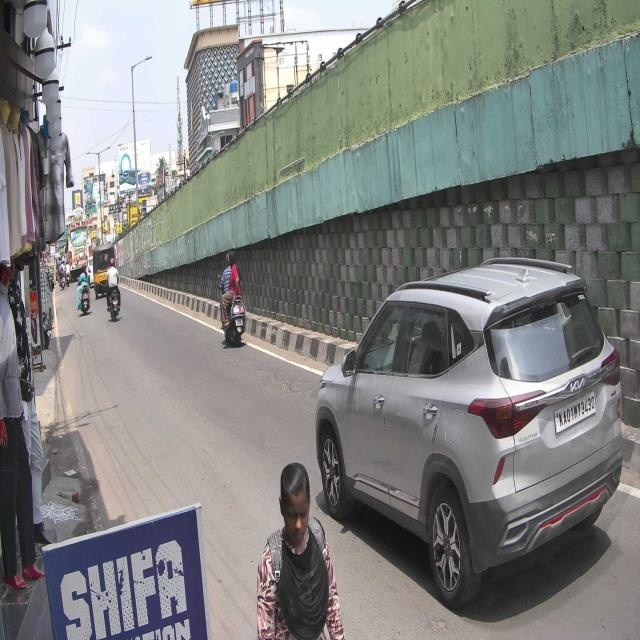

Results saved to /content/runs/detect/predict

 3644_TN30BP4302_1775750053000_2026-04-09-15-54-13_background_jpg.rf.857910c3b362f4729ee89b239b420ed0.jpg


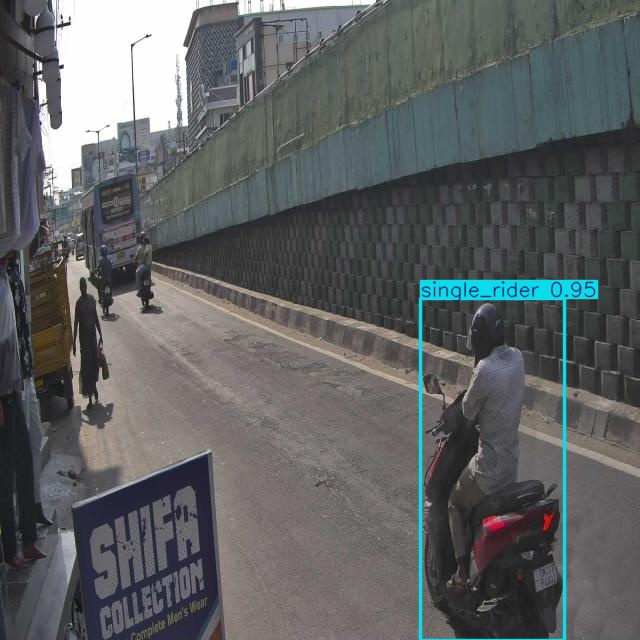

Results saved to /content/runs/detect/predict

 107_TN30BS3856_1775468725000_2026-04-06-09-45-25_background_jpg.rf.4f4e39ed6ef55b3dbc05924326ae89ae.jpg


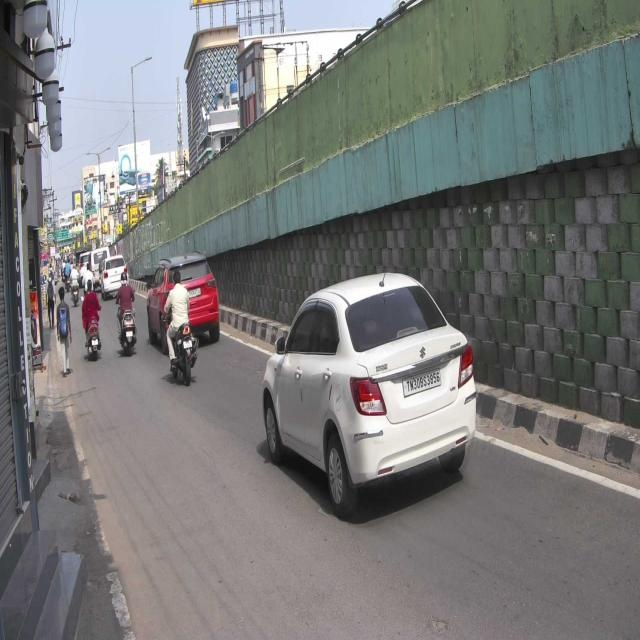

Results saved to /content/runs/detect/predict

 1606_TN30E87_1775475171000_2026-04-06-11-32-51_background_jpg.rf.0bfff6c55573b279a14087a7f03e6035.jpg


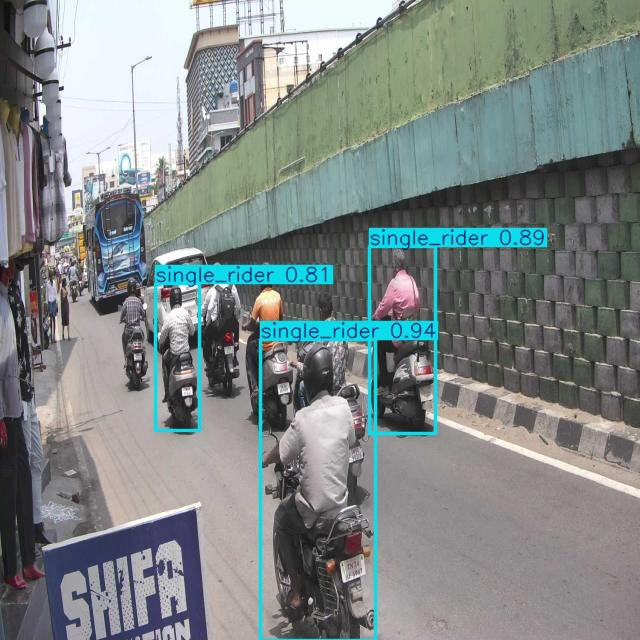

Results saved to /content/runs/detect/predict

 overload-380-_jpg.rf.3470326549554669c52e3e5a89814413.jpg


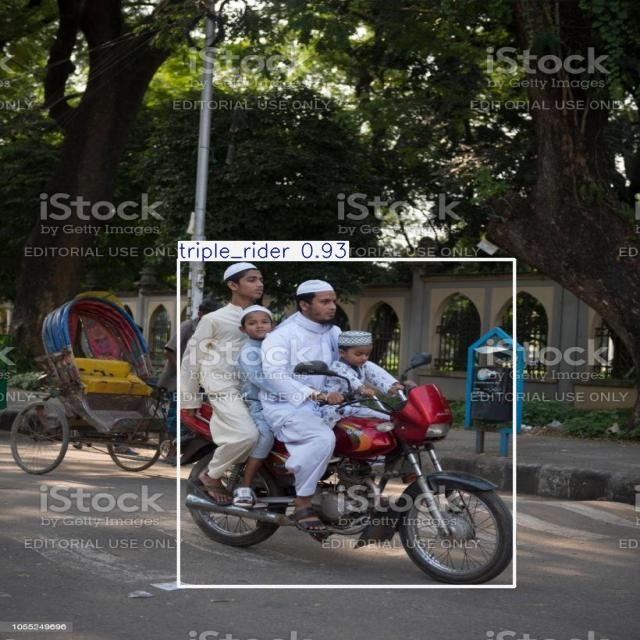

Results saved to /content/runs/detect/predict

 3620_TM64AB2394_1775749919000_2026-04-09-15-51-59_background_jpg.rf.623389325cff9254bcd9ff0e7624feaf.jpg


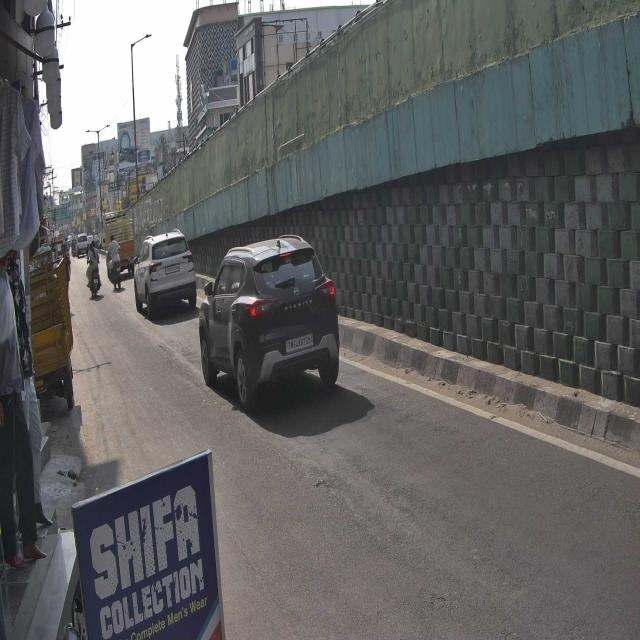

Results saved to /content/runs/detect/predict

 3604_6400_1775749812000_2026-04-09-15-50-12_background_jpg.rf.1f2e7428d54520e9a71a56ba94f1e98b.jpg


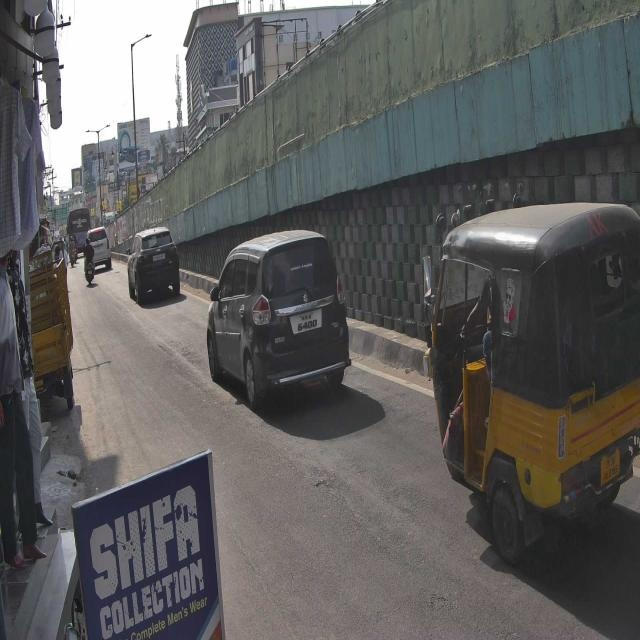

Results saved to /content/runs/detect/predict

 3803_TN30CJ7477_1775751274000_2026-04-09-16-14-34_background_jpg.rf.770a67586562f5618a37be1f5f876623.jpg


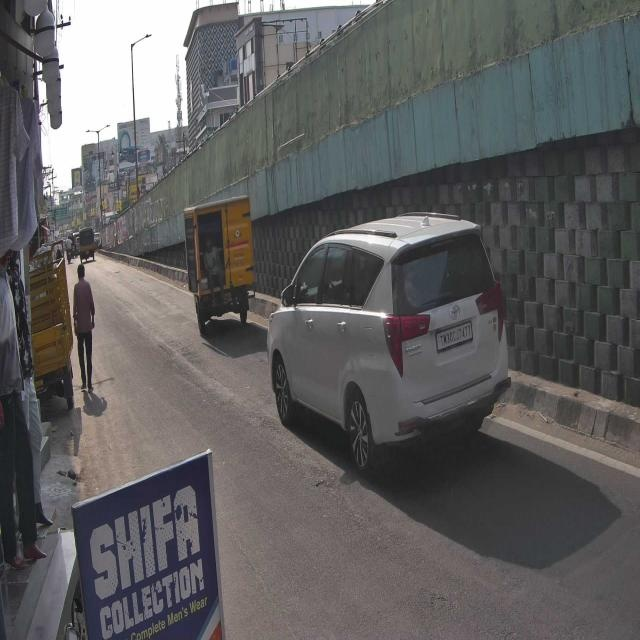

Results saved to /content/runs/detect/predict

 4998_TN49BP363_1775841734000_2026-04-10-17-22-14_background_jpg.rf.257349383436ab646ea293280cd39bd9.jpg


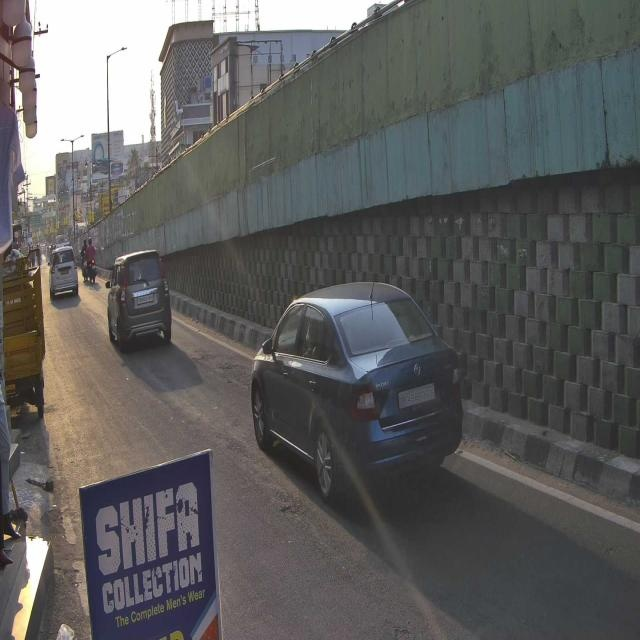

In [ ]:
import random
import os
from IPython.display import display, Image

image_dir = "/content/drive/MyDrive/traffic_project/datasets/triple_dataset/test/images"

sample_images = random.sample(os.listdir(image_dir), 10)

for img in sample_images:

    image_path = os.path.join(image_dir, img)

    results = best_model.predict(
        source=image_path,
        conf=0.5,
        save=True,
        verbose=False
    )

    print("\n", img)

    display(Image("/content/runs/detect/predict/" + img))

In [ ]:
import random
import os

triple_images = []

label_dir = "/content/drive/MyDrive/traffic_project/datasets/triple_dataset/test/labels"
image_dir = "/content/drive/MyDrive/traffic_project/datasets/triple_dataset/test/images"

for file in os.listdir(label_dir):

    with open(os.path.join(label_dir,file)) as f:

        lines = f.readlines()

        for line in lines:

            cls = int(line.split()[0])

            if cls == 2:
                img_file = file.replace(".txt",".jpg")
                triple_images.append(img_file)
                break

print("Triple Rider Images =",len(triple_images))

Triple Rider Images = 38


Results saved to /content/runs/detect/predict


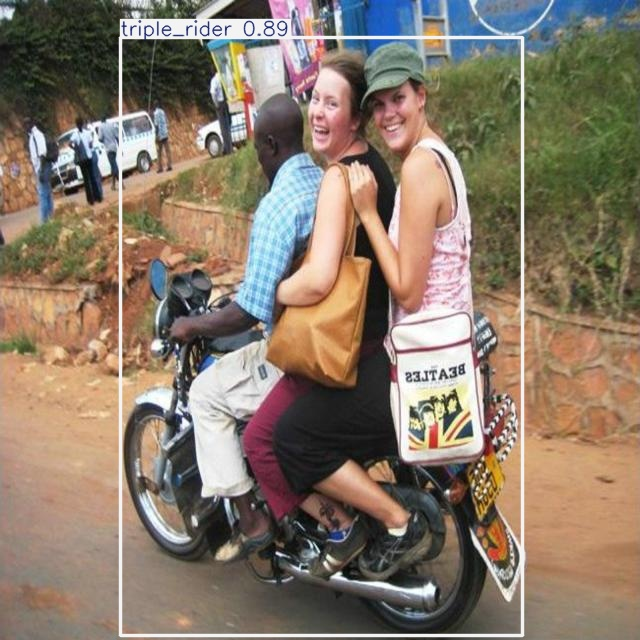

Results saved to /content/runs/detect/predict


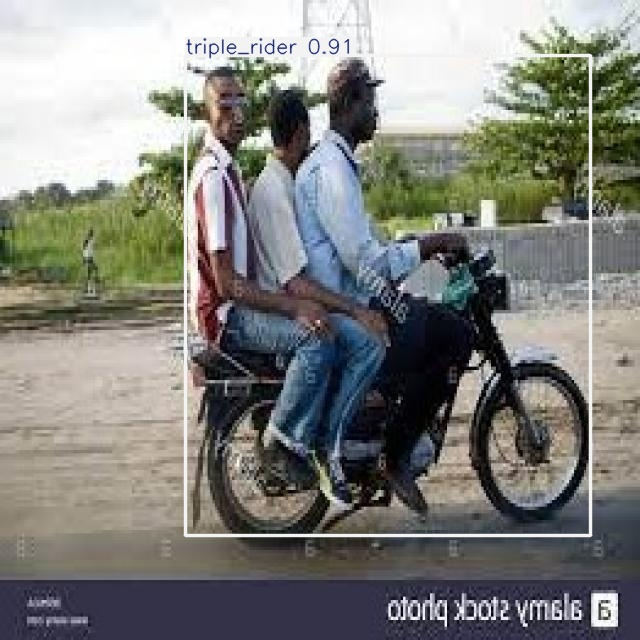

Results saved to /content/runs/detect/predict


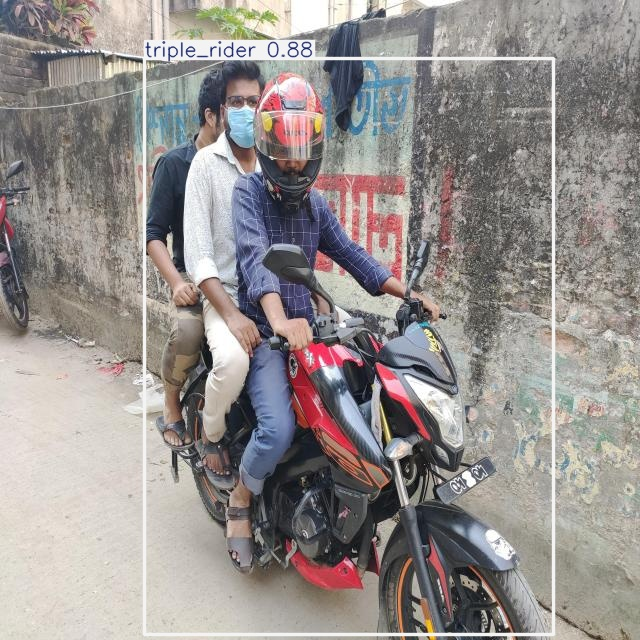

Results saved to /content/runs/detect/predict


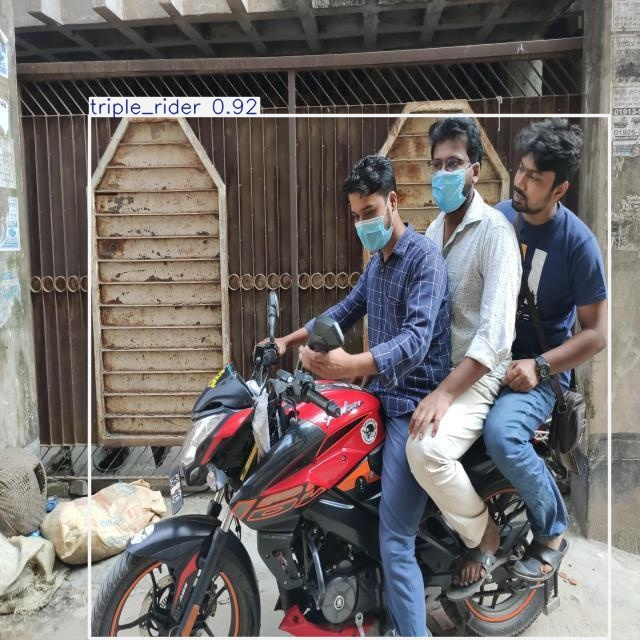

Results saved to /content/runs/detect/predict


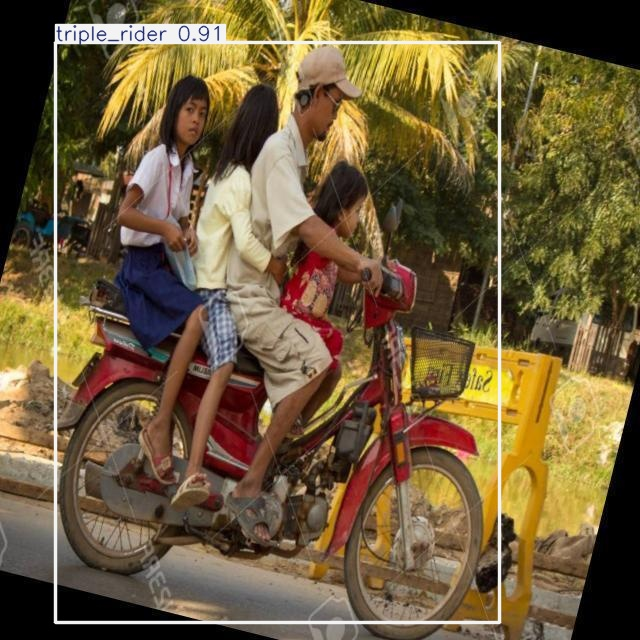

Results saved to /content/runs/detect/predict


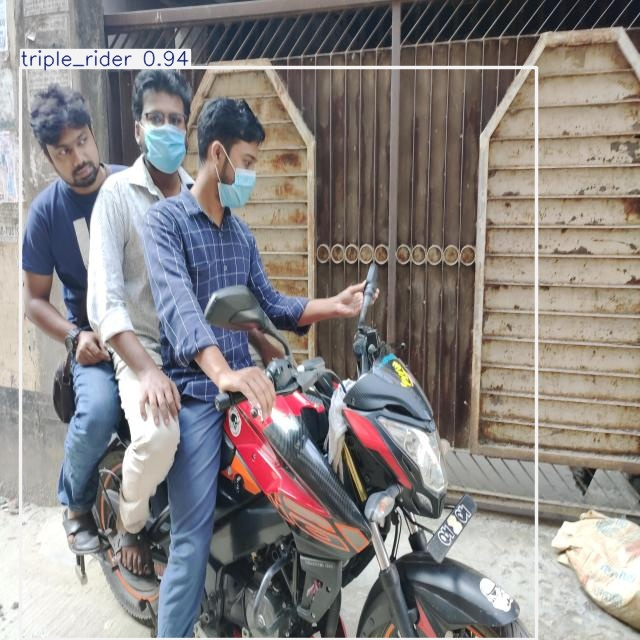

Results saved to /content/runs/detect/predict


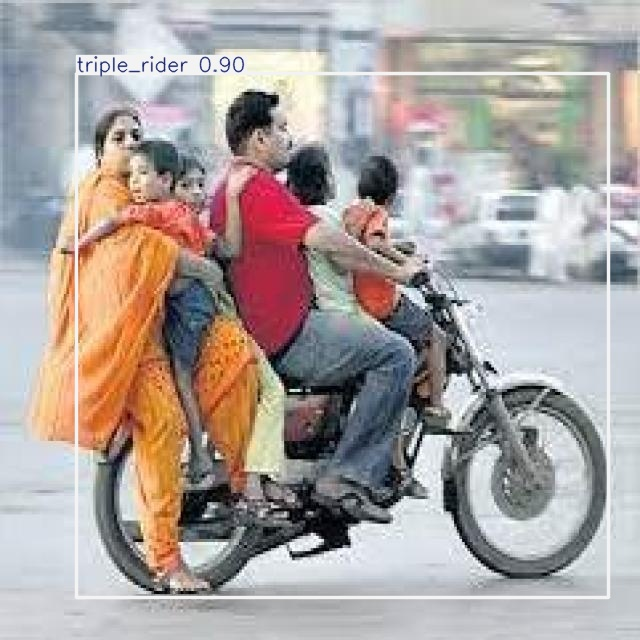

Results saved to /content/runs/detect/predict


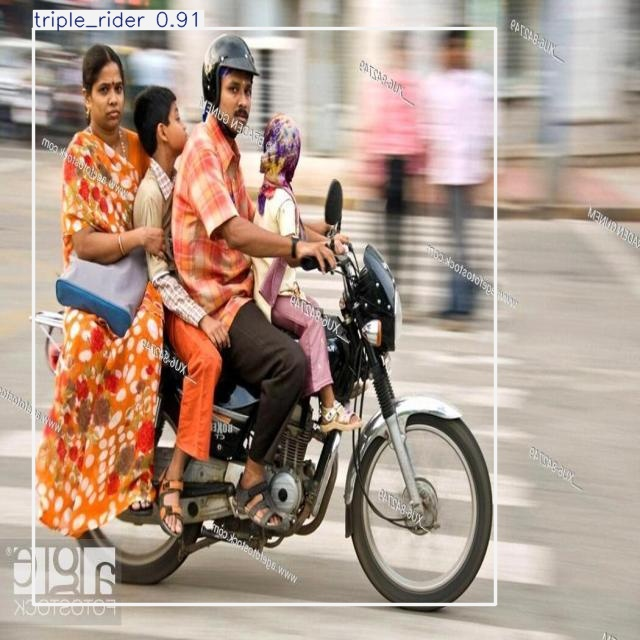

Results saved to /content/runs/detect/predict


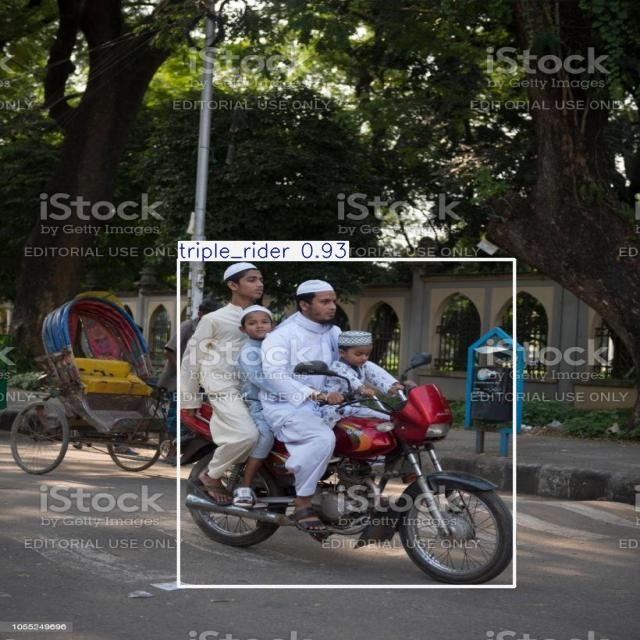

Results saved to /content/runs/detect/predict


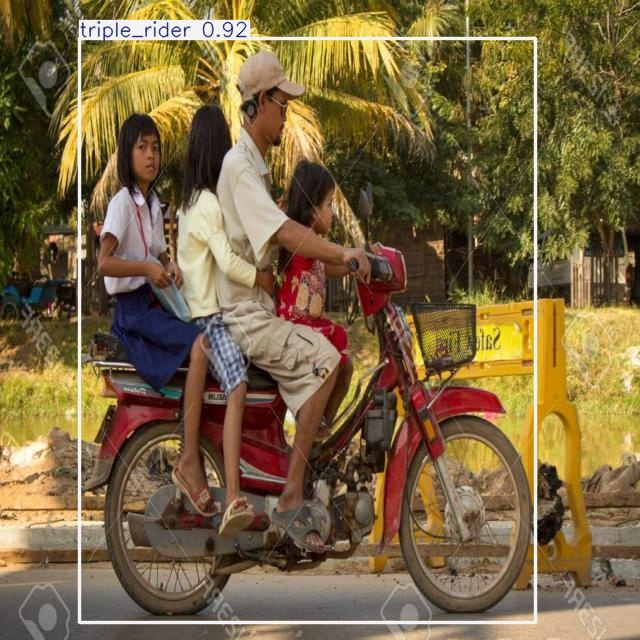

In [ ]:
sample = random.sample(triple_images,10)

for img in sample:

    path = os.path.join(image_dir,img)

    best_model.predict(
        source=path,
        conf=0.5,
        save=True,
        verbose=False
    )

    display(Image("/content/runs/detect/predict/"+img))

In [ ]:
if cls == 2 and confidence > 0.7:
    violation = "Triple Riding"
else:
    violation = "No Violation"